# Argus Multi-GNN Training

Train the edge-level AML transaction classifier.

**Kaggle setup:**
1. Add your dataset: Sidebar → Add Input → Upload → upload `tx.csv`
2. Settings → Accelerator → GPU P100 (or T4)
3. Run All
4. Download `multignn_model.pt` and `multignn_meta.json` from the Output tab

**Colab setup:**
1. Runtime → Change runtime type → T4 GPU
2. Mount Google Drive or upload CSV
3. Update `CSV_FILES` path below
4. Run All

In [1]:
%pip install -q torch_geometric
%pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.5.0+cu121.html 2>/dev/null || true

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


The system cannot find the path specified.
'true' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
#──────────────────────────────────────────────────────────────────────────────
# CONFIG
#──────────────────────────────────────────────────────────────────────────────
import torch

# Auto-detect platform and find the CSV

csv_path = r"C:\Users\Archit\OneDrive\Desktop\Datasets\TransXion\data\tx.csv"
if csv_path:
    print(f"Found dataset: {csv_path}")
else:
    print("Dataset not found! Upload tx.csv via Add Input (Kaggle) or files.upload() (Colab)")

CSV_FILES  = [csv_path] if csv_path else ["tx.csv"]  # override manually if needed

EPOCHS     = 50
HIDDEN     = 128
LAYERS     = 3
LR         = 1e-3
BATCH_SIZE = 4096
POS_WEIGHT = 15.0
MAX_ROWS   = 550000    # None = all rows

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if MAX_ROWS:
    print(f"Capping at {MAX_ROWS:,} rows")

Found dataset: C:\Users\Archit\OneDrive\Desktop\Datasets\TransXion\data\tx.csv
Device: cuda
Capping at 550,000 rows


In [3]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [4]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                             recall_score, average_precision_score)
from torch_geometric.nn import PNAConv
from torch_geometric.utils import degree

warnings.filterwarnings("ignore")

c:\Users\Archit\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#──────────────────────────────────────────────────────────────────────────────
# Data loading & column normalisation
#──────────────────────────────────────────────────────────────────────────────

def normalize_columns(df, filename):
    if "Sender_account" in df.columns:
        df = df.rename(columns={
            "Sender_account": "Account", "Receiver_account": "Account.1",
            "Amount": "Amount Paid", "Payment_currency": "Payment Currency",
            "Received_currency": "Receiving Currency", "Payment_type": "Payment Format",
            "Is_laundering": "Is Laundering", "Sender_bank_location": "From Bank",
            "Receiver_bank_location": "To Bank",
        })
        if "Timestamp" not in df.columns and "Date" in df.columns:
            df["Timestamp"] = df["Date"] + (" " + df["Time"] if "Time" in df.columns else "")
        if "Amount Received" not in df.columns:
            df["Amount Received"] = df["Amount Paid"]
        print(f"  {filename}: mapped SAML-D columns")
        return df

    if "From Account" in df.columns and "Account" not in df.columns:
        df = df.rename(columns={"From Account": "Account", "To Account": "Account.1"})
        print(f"  {filename}: mapped TransXion columns")
    elif "Account" in df.columns and "Account.1" not in df.columns:
        cols = list(df.columns)
        second = [i for i, c in enumerate(cols) if c == "Account"]
        if len(second) >= 2:
            cols[second[1]] = "Account.1"
            df.columns = cols
    return df


def load_datasets(csv_files, max_rows=None):
    dfs = []
    for fname in csv_files:
        p = Path(fname)
        if not p.exists():
            raise FileNotFoundError(f"Cannot find {fname}")
        print(f"Loading {p.name}...")
        chunk = pd.read_csv(p, nrows=max_rows)
        chunk = normalize_columns(chunk, p.name)
        pos = chunk['Is Laundering'].sum()
        print(f"  {len(chunk):,} rows, {pos:,.0f} positives ({100*chunk['Is Laundering'].mean():.3f}%)")
        dfs.append(chunk)
    df = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal: {len(df):,} rows, {df['Is Laundering'].sum():,.0f} positives")
    return df

In [6]:
#──────────────────────────────────────────────────────────────────────────────
# Graph construction
#──────────────────────────────────────────────────────────────────────────────

def _port_index(endpoint, E):
    order = np.zeros(E, dtype=np.float32)
    counter = {}
    for i, v in enumerate(endpoint):
        c = counter.get(v, 0)
        order[i] = c
        counter[v] = c + 1
    return order


def build_graph(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="mixed")
    df.sort_values("Timestamp", inplace=True)
    df.reset_index(drop=True, inplace=True)

    src_key = df["From Bank"].astype(str) + ":" + df["Account"].astype(str)
    dst_key = df["To Bank"].astype(str) + ":" + df["Account.1"].astype(str)

    keep = src_key.values != dst_key.values
    df = df[keep].reset_index(drop=True)
    src_key = src_key[keep].reset_index(drop=True)
    dst_key = dst_key[keep].reset_index(drop=True)

    nodes = pd.Index(pd.unique(pd.concat([src_key, dst_key])))
    node_id = {k: i for i, k in enumerate(nodes)}
    src = src_key.map(node_id).to_numpy()
    dst = dst_key.map(node_id).to_numpy()
    N, E = len(nodes), len(df)
    print(f"Graph: {N:,} accounts, {E:,} transactions")

    amount = df["Amount Paid"].to_numpy(dtype=np.float64)
    log_amt = np.log1p(np.clip(amount, 0, None)).astype(np.float32)
    log_amt = (log_amt - log_amt.mean()) / (log_amt.std() + 1e-6)

    ts = df["Timestamp"].astype("int64").to_numpy()
    t_norm = ((ts - ts.min()) / (ts.max() - ts.min() + 1)).astype(np.float32)

    hour = df["Timestamp"].dt.hour.to_numpy().astype(np.float32)
    hour_sin = np.sin(2 * np.pi * hour / 24).astype(np.float32)
    hour_cos = np.cos(2 * np.pi * hour / 24).astype(np.float32)
    dow = df["Timestamp"].dt.dayofweek.to_numpy().astype(np.float32)
    dow_sin = np.sin(2 * np.pi * dow / 7).astype(np.float32)
    dow_cos = np.cos(2 * np.pi * dow / 7).astype(np.float32)

    is_cross_bank = (df["From Bank"].astype(str) != df["To Bank"].astype(str)).astype(np.float32).to_numpy()
    cur_codes, cur_uniq = pd.factorize(df["Receiving Currency"])
    fmt_codes, fmt_uniq = pd.factorize(df["Payment Format"])

    high_risk_cur = df["Receiving Currency"].isin(["Bitcoin", "BTC", "XRP", "ETH"]).to_numpy().astype(np.float32)
    high_risk_fmt = df["Payment Format"].isin(["Cheque", "Cash", "Cash Deposit"]).to_numpy().astype(np.float32)
    cross_x_cur = (is_cross_bank * high_risk_cur).astype(np.float32)
    cross_x_fmt = (is_cross_bank * high_risk_fmt).astype(np.float32)

    out_port = _port_index(src, E)
    in_port = _port_index(dst, E)
    out_port_n = (out_port / (out_port.max() + 1)).astype(np.float32)
    in_port_n = (in_port / (in_port.max() + 1)).astype(np.float32)

    y = df["Is Laundering"].to_numpy(dtype=np.float32)

    fwd_attr = np.stack([
        log_amt, t_norm, out_port_n, in_port_n,
        np.zeros(E, np.float32),
        hour_sin, hour_cos, dow_sin, dow_cos, is_cross_bank,
        cross_x_cur, cross_x_fmt,
        cur_codes.astype(np.float32), fmt_codes.astype(np.float32),
    ], axis=1)
    rev_attr = fwd_attr.copy()
    rev_attr[:, 2], rev_attr[:, 3] = in_port_n, out_port_n
    rev_attr[:, 4] = 1.0

    edge_index = np.concatenate([np.stack([src, dst]), np.stack([dst, src])], axis=1)
    edge_attr = np.concatenate([fwd_attr, rev_attr], axis=0)

    in_deg = np.bincount(dst, minlength=N).astype(np.float32)
    out_deg = np.bincount(src, minlength=N).astype(np.float32)
    recv = np.bincount(dst, weights=amount, minlength=N).astype(np.float32)
    sent = np.bincount(src, weights=amount, minlength=N).astype(np.float32)
    x = np.stack([np.log1p(in_deg), np.log1p(out_deg), np.log1p(recv), np.log1p(sent)], axis=1)
    x = (x - x.mean(0)) / (x.std(0) + 1e-6)

    edge_index_t = torch.tensor(edge_index, dtype=torch.long)
    d = degree(edge_index_t[1], num_nodes=N, dtype=torch.long)
    max_deg = min(int(d.max().item()), 500)
    deg = torch.bincount(d.clamp(max=max_deg), minlength=max_deg + 1)

    meta = {
        "n_nodes": N, "n_edges": E,
        "n_currencies": int(len(cur_uniq)), "n_formats": int(len(fmt_uniq)),
        "currencies": list(map(str, cur_uniq)), "formats": list(map(str, fmt_uniq)),
        "node_dim": 4, "edge_cont_dim": 12,
    }

    return {
        "x": torch.tensor(x, dtype=torch.float),
        "edge_index": edge_index_t,
        "edge_attr": torch.tensor(edge_attr, dtype=torch.float),
        "y": torch.tensor(y, dtype=torch.float),
        "label_index": torch.tensor(np.stack([src, dst]), dtype=torch.long),
        "t_edge": torch.tensor(t_norm, dtype=torch.float),
        "deg": deg,
        "meta": meta,
    }

In [7]:
#──────────────────────────────────────────────────────────────────────────────
# Model architecture
#──────────────────────────────────────────────────────────────────────────────

class MultiGNN(nn.Module):
    def __init__(self, node_dim=4, edge_cont_dim=12, n_currencies=16, n_formats=8,
                 hidden=64, layers=3, dropout=0.2, emb_dim=8, deg=None):
        super().__init__()
        self.cur_emb = nn.Embedding(n_currencies + 1, emb_dim)
        self.fmt_emb = nn.Embedding(n_formats + 1, emb_dim)
        edge_in = edge_cont_dim + 2 * emb_dim
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden),
        )
        self.node_enc = nn.Linear(node_dim, hidden)

        aggregators = ["mean", "max", "min", "std"]
        scalers = ["identity", "amplification", "attenuation"]
        if deg is None:
            deg = torch.ones(100, dtype=torch.long)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(layers):
            self.convs.append(PNAConv(
                in_channels=hidden, out_channels=hidden,
                aggregators=aggregators, scalers=scalers,
                deg=deg, edge_dim=hidden,
                towers=1, pre_layers=1, post_layers=1,
            ))
            self.norms.append(nn.BatchNorm1d(hidden))
        self.drop = nn.Dropout(dropout)
        self.edge_cont_dim = edge_cont_dim
        self.head = nn.Sequential(
            nn.Linear(4 * hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def _encode_edges(self, edge_attr):
        cont = edge_attr[:, :self.edge_cont_dim]
        cur = self.cur_emb(edge_attr[:, 12].long().clamp(min=0))
        fmt = self.fmt_emb(edge_attr[:, 13].long().clamp(min=0))
        return self.edge_enc(torch.cat([cont, cur, fmt], dim=-1))

    def encode_nodes(self, x, edge_index, edge_attr):
        e = self._encode_edges(edge_attr)
        h = F.relu(self.node_enc(x))
        for conv, norm in zip(self.convs, self.norms):
            h = conv(h, edge_index, e)
            h = norm(h)
            h = self.drop(F.relu(h))
        return h

    def classify_edges(self, h, label_index, edge_attr_targets):
        hs, hd = h[label_index[0]], h[label_index[1]]
        e = self._encode_edges(edge_attr_targets)
        return self.head(torch.cat([hs, hd, hs * hd, e], dim=-1)).squeeze(-1)

    def forward(self, x, edge_index, edge_attr, label_index, edge_attr_targets):
        h = self.encode_nodes(x, edge_index, edge_attr)
        return self.classify_edges(h, label_index, edge_attr_targets)

In [8]:
#──────────────────────────────────────────────────────────────────────────────
# Training utilities
#──────────────────────────────────────────────────────────────────────────────

def temporal_split(t_edge, train=0.75, val=0.15):
    order = torch.argsort(t_edge)
    n = len(order)
    return (order[:int(n * train)],
            order[int(n * train):int(n * (train + val))],
            order[int(n * (train + val)):])


@torch.no_grad()
def predict(model, x, edge_index, edge_attr, label_index, edge_attr_targets, batch_size=8192):
    model.eval()
    h = model.encode_nodes(x, edge_index, edge_attr)
    probs = []
    for s in range(0, label_index.size(1), batch_size):
        chunk = label_index[:, s:s + batch_size]
        ea = edge_attr_targets[s:s + batch_size]
        probs.append(torch.sigmoid(model.classify_edges(h, chunk, ea)))
    return torch.cat(probs).cpu().numpy()


@torch.no_grad()
def evaluate(model, x, edge_index, edge_attr, label_index, y, batch_size=8192,
             edge_attr_targets=None, sweep=False):
    p = predict(model, x, edge_index, edge_attr, label_index, edge_attr_targets, batch_size)
    l = y.cpu().numpy()
    auc = roc_auc_score(l, p) if len(set(l)) > 1 else float("nan")
    ap = average_precision_score(l, p) if len(set(l)) > 1 else float("nan")

    thr = 0.5
    if sweep and len(set(l)) > 1:
        best_f1, best_t = -1.0, 0.5
        for t in np.linspace(0.05, 0.95, 37):
            f1 = f1_score(l, (p >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thr = float(best_t)
    pred = (p >= thr).astype(int)
    return {
        "f1": round(float(f1_score(l, pred, zero_division=0)), 4),
        "precision": round(float(precision_score(l, pred, zero_division=0)), 4),
        "recall": round(float(recall_score(l, pred, zero_division=0)), 4),
        "auc": round(float(auc), 4) if auc == auc else None,
        "ap": round(float(ap), 4) if ap == ap else None,
        "threshold": round(thr, 3),
    }

In [9]:
#──────────────────────────────────────────────────────────────────────────────
# Training loop
#──────────────────────────────────────────────────────────────────────────────

def train(bundle, epochs=50, hidden=128, layers=3, lr=1e-3,
          batch_size=4096, pos_weight_val=7.1):
    x = bundle["x"].to(DEVICE)
    edge_index = bundle["edge_index"].to(DEVICE)
    edge_attr = bundle["edge_attr"].to(DEVICE)
    y = bundle["y"].to(DEVICE)
    label_index = bundle["label_index"].to(DEVICE)
    t_edge = bundle["t_edge"]
    meta = bundle["meta"]
    deg = bundle["deg"].to(DEVICE)

    tr, va, te = temporal_split(t_edge)
    tr, va, te = tr.to(DEVICE), va.to(DEVICE), te.to(DEVICE)
    print(f"Split — train {len(tr):,} | val {len(va):,} | test {len(te):,} "
          f"| positives {int(y[tr].sum()):,}/{len(tr):,} ({100*y[tr].float().mean():.3f}%)")

    model = MultiGNN(meta["node_dim"], meta["edge_cont_dim"], meta["n_currencies"],
                     meta["n_formats"], hidden=hidden, layers=layers, deg=deg).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

    n_pos = max(float(y[tr].sum()), 1.0)
    n_neg = len(tr) - n_pos
    auto_pw = min(n_neg / n_pos, 200.0)
    effective_pw = max(pos_weight_val, auto_pw)
    pos_w = torch.tensor([effective_pw], device=DEVICE)
    print(f"pos_weight: requested={pos_weight_val}, auto={auto_pw:.1f}, using={effective_pw:.1f}")

    E = label_index.size(1)
    edge_attr_fwd = edge_attr[:E]
    li_tr, y_tr, ea_tr = label_index[:, tr], y[tr], edge_attr_fwd[tr]

    best_val_f1, best_state = -1.0, None
    patience_counter = 0
    patience = max(epochs // 4, 5)
    history = []

    print(f"\nTraining {epochs} epochs (patience={patience})...\n")
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        opt.zero_grad()
        h = model.encode_nodes(x, edge_index, edge_attr)
        out = model.classify_edges(h, li_tr, ea_tr)
        loss = F.binary_cross_entropy_with_logits(out, y_tr, pos_weight=pos_w)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        scheduler.step()

        vm = evaluate(model, x, edge_index, edge_attr, label_index[:, va], y[va],
                      batch_size, edge_attr_targets=edge_attr_fwd[va])

        star = ""
        if vm["f1"] > best_val_f1:
            best_val_f1 = vm["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            star = " ★"
        else:
            patience_counter += 1

        elapsed = time.time() - t_start
        eta = elapsed / epoch * (epochs - epoch)
        history.append({"epoch": epoch, "loss": loss.item(), **vm})

        print(f"  [{epoch:3d}/{epochs}] loss={loss.item():.4f}  "
              f"F1={vm['f1']:.4f}  AUC={vm['auc']:.4f}  "
              f"P={vm['precision']:.4f}  R={vm['recall']:.4f}  "
              f"({time.time()-t0:.1f}s, ETA {eta:.0f}s){star}")

        if patience_counter >= patience and epoch >= 8:
            print(f"\n  Early stopping — no improvement for {patience} epochs")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(DEVICE)
        print(f"\nRestored best model (val F1={best_val_f1:.4f})")

    test_m = evaluate(model, x, edge_index, edge_attr, label_index[:, te], y[te],
                      batch_size, edge_attr_targets=edge_attr_fwd[te], sweep=True)
    print(f"\n{'='*60}")
    print(f"TEST RESULTS")
    print(f"  F1:        {test_m['f1']:.4f}")
    print(f"  AUC:       {test_m['auc']:.4f}")
    print(f"  AP:        {test_m['ap']:.4f}")
    print(f"  Precision: {test_m['precision']:.4f}")
    print(f"  Recall:    {test_m['recall']:.4f}")
    print(f"  Threshold: {test_m['threshold']:.3f}")
    print(f"{'='*60}")

    return model, test_m, meta, bundle["deg"], history

In [10]:
# Load data & build graph
df = load_datasets(CSV_FILES, max_rows=MAX_ROWS)
bundle = build_graph(df)

Loading tx.csv...
  tx.csv: mapped TransXion columns
  550,000 rows, 718 positives (0.131%)

Total: 550,000 rows, 718 positives
Graph: 17,023 accounts, 550,000 transactions


In [11]:
print(bundle["x"].shape, bundle["x"].dtype)
print(bundle["edge_index"].shape, bundle["edge_index"].dtype)
print(bundle["edge_attr"].shape, bundle["edge_attr"].dtype)
print(bundle["y"].shape, bundle["y"].dtype)

torch.Size([17023, 4]) torch.float32
torch.Size([2, 1100000]) torch.int64
torch.Size([1100000, 14]) torch.float32
torch.Size([550000]) torch.float32


In [12]:
# Train!
model, metrics, meta, deg, history = train(
    bundle,
    epochs=EPOCHS,
    hidden=HIDDEN,
    layers=LAYERS,
    lr=LR,
    batch_size=BATCH_SIZE,
    pos_weight_val=POS_WEIGHT,
)

Split — train 412,500 | val 82,500 | test 55,000 | positives 394/412,500 (0.096%)
pos_weight: requested=15.0, auto=200.0, using=200.0

Training 50 epochs (patience=12)...

  [  1/50] loss=0.7241  F1=0.0000  AUC=0.8791  P=0.0000  R=0.0000  (13.9s, ETA 682s) ★
  [  2/50] loss=0.3713  F1=0.0000  AUC=0.9223  P=0.0000  R=0.0000  (9.5s, ETA 562s)
  [  3/50] loss=0.2632  F1=0.0000  AUC=0.9491  P=0.0000  R=0.0000  (11.1s, ETA 541s)
  [  4/50] loss=0.2094  F1=0.1643  AUC=0.9617  P=0.3433  R=0.1080  (12.2s, ETA 538s) ★
  [  5/50] loss=0.1714  F1=0.3681  AUC=0.9686  P=0.3261  R=0.4225  (13.3s, ETA 540s) ★
  [  6/50] loss=0.1526  F1=0.4099  AUC=0.9704  P=0.3439  R=0.5070  (14.0s, ETA 542s) ★
  [  7/50] loss=0.1418  F1=0.4104  AUC=0.9708  P=0.3406  R=0.5164  (13.6s, ETA 538s) ★
  [  8/50] loss=0.1310  F1=0.4211  AUC=0.9714  P=0.3361  R=0.5634  (12.9s, ETA 527s) ★
  [  9/50] loss=0.1256  F1=0.4293  AUC=0.9723  P=0.3369  R=0.5915  (12.9s, ETA 516s) ★
  [ 10/50] loss=0.1203  F1=0.4336  AUC=0.9732  P=0

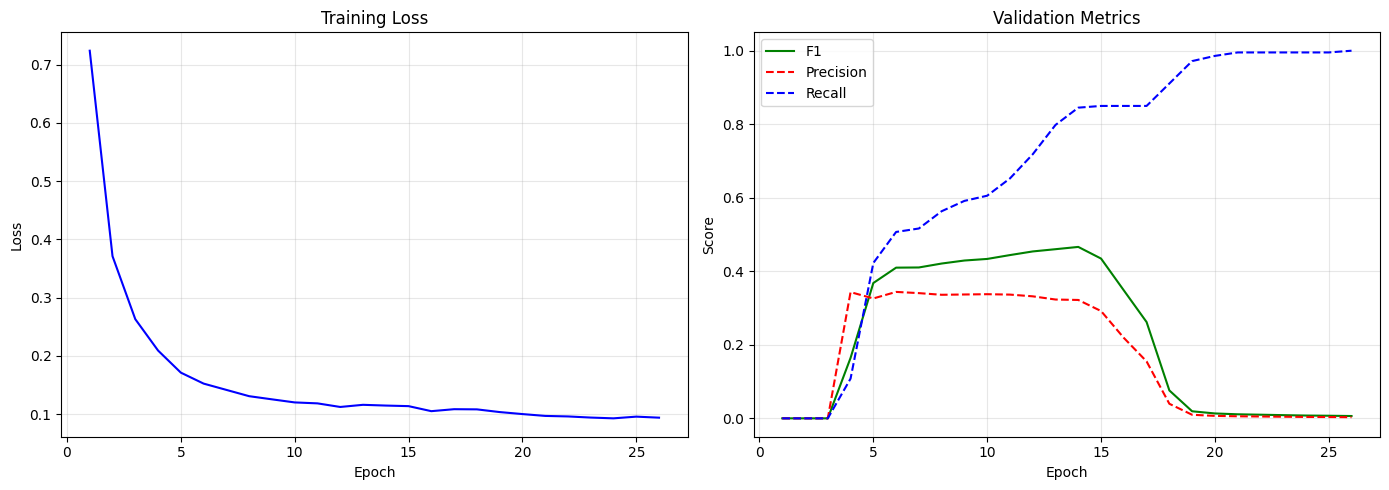

In [13]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_list = [h["epoch"] for h in history]
ax1.plot(epochs_list, [h["loss"] for h in history], "b-")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_list, [h["f1"] for h in history], "g-", label="F1")
ax2.plot(epochs_list, [h["precision"] for h in history], "r--", label="Precision")
ax2.plot(epochs_list, [h["recall"] for h in history], "b--", label="Recall")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score"); ax2.set_title("Validation Metrics")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Save model files
# On Kaggle: files saved here appear in the Output tab for download
# On Colab: use files.download() below

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
MODEL_FILE = OUTPUT_DIR / "multignn_model.pt"
META_FILE = OUTPUT_DIR / "multignn_meta.json"

model_cpu = model.cpu()

torch.save({
    "state_dict": model_cpu.state_dict(),
    "config": {
        "node_dim": meta["node_dim"],
        "edge_cont_dim": meta["edge_cont_dim"],
        "n_currencies": meta["n_currencies"],
        "n_formats": meta["n_formats"],
        "hidden": HIDDEN,
        "layers": LAYERS,
    },
    "deg": deg.cpu(),
    "metrics": metrics,
}, MODEL_FILE)

META_FILE.write_text(json.dumps({
    "metrics": metrics,
    "encoders": {
        "currencies": meta["currencies"],
        "formats": meta["formats"],
    }
}, indent=2))

print(f"Saved {MODEL_FILE} ({MODEL_FILE.stat().st_size / 1024:.0f} KB)")
print(f"Saved {META_FILE}")
print(f"\nMetrics: {json.dumps(metrics, indent=2)}")
print(f"\n→ On Kaggle: download from the Output tab on the right")
print(f"→ On Colab: run the next cell")

Saved multignn_model.pt (3832 KB)
Saved multignn_meta.json

Metrics: {
  "f1": 0.4221,
  "precision": 0.3299,
  "recall": 0.5856,
  "auc": 0.9786,
  "ap": 0.2814,
  "threshold": 0.95
}

→ On Kaggle: download from the Output tab on the right
→ On Colab: run the next cell


In [15]:
from pathlib import Path

SAVE_DIR = Path(r"C:\Users\Archit\Documents\GNN_Model")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = SAVE_DIR / "model.pth"
META_FILE = SAVE_DIR / "meta.pt"

torch.save(model.state_dict(), MODEL_FILE)
torch.save(meta, META_FILE)

print("Saved to:", MODEL_FILE)
print("Saved to:", META_FILE)

Saved to: C:\Users\Archit\Documents\GNN_Model\model.pth
Saved to: C:\Users\Archit\Documents\GNN_Model\meta.pt
